In [1]:
!pip install -q pandas numpy pyarrow matplotlib tensorflow scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import json

In [2]:
USE_PARQUET = True  # set False to use uk_rainfall_temp_2010_2019.csv instead

if USE_PARQUET:
    df = pd.read_parquet("daily_uk_2m_weather.parquet")
    df["date"] = pd.to_datetime(df["date"])
    df = df[(df["date"] >= "2015-01-01") & (df["date"] <= "2024-12-31")]
    daily = df.groupby("date").agg({
        "min_temp °c": "mean",
        "max_temp °c": "mean",
        "rain mm": "sum"
    }).reset_index()
    daily["temp"] = (daily["min_temp °c"] + daily["max_temp °c"]) / 2
    weekly = daily.set_index("date")[["temp", "rain mm"]].resample("W").mean().dropna()
else:
    # Smaller backup file
    raw = pd.read_csv("uk_rainfall_temp_2010_2019.csv")
    raw = raw[raw["Type of period"] == "Monthly"]
    raw["date"] = pd.to_datetime(raw["Year"].astype(str) + "-" + raw["Period"], format="%Y-%b")
    weekly = raw.set_index("date")[["Avg temp(in centigrade)", "Avg rainfall(in mm)"]]
    weekly.columns = ["temp", "rain mm"]

print(weekly.tail())
print("Weeks:", len(weekly))

                 temp   rain mm
date                           
2024-10-20  12.357143  6.000000
2024-10-27  10.928571  2.057143
2024-11-03  12.000000  0.257143
2024-11-10  12.428571  0.200000
2024-11-17   9.500000  0.000000
Weeks: 501


In [3]:
SEQ_LEN = 12
HORIZON = 4
TEST_WEEKS = 26

target = weekly["temp"].values.reshape(-1, 1)
scaler = MinMaxScaler()
scaled = scaler.fit_transform(target)

def make_sequences(data, seq_len):
    X, y = [], []
    for i in range(seq_len, len(data)):
        X.append(data[i-seq_len:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X, y = make_sequences(scaled, SEQ_LEN)
split = len(X) - TEST_WEEKS
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(SEQ_LEN, 1)),
    Dropout(0.2),
    LSTM(25),
    Dense(1)
])
model.compile(optimizer="adam", loss="mse")
model.fit(X_train, y_train, epochs=30, batch_size=16, verbose=1)

pred_scaled = model.predict(X_test, verbose=0).flatten()
y_true = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
y_pred = scaler.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()
print("Training done.")

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0709
Epoch 2/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0179
Epoch 3/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0157
Epoch 4/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0150
Epoch 5/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0128
Epoch 6/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0106
Epoch 7/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0080
Epoch 8/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0074
Epoch 9/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0074
Epoch 10/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0077
Epoch 11/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0068
Epoch 12/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0062
Epoch 13/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0063
Epoch 14/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0060
Epoch 15/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0062
Epoch 16/30
29/

In [4]:
rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
mae = float(mean_absolute_error(y_true, y_pred))

metrics_c = {
    "model": "L2 LSTM weather",
    "target": "weekly UK mean temperature",
    "horizon_weeks": HORIZON,
    "rmse_celsius": round(rmse, 4),
    "mae_celsius": round(mae, 4),
    "test_weeks": TEST_WEEKS,
}
print(f"RMSE: {metrics_c['rmse_celsius']} °C")
print(f"MAE:  {metrics_c['mae_celsius']} °C")

with open("metrics_c.json", "w") as f:
    json.dump(metrics_c, f, indent=2)

RMSE: 3.6654 °C
MAE:  2.5762 °C


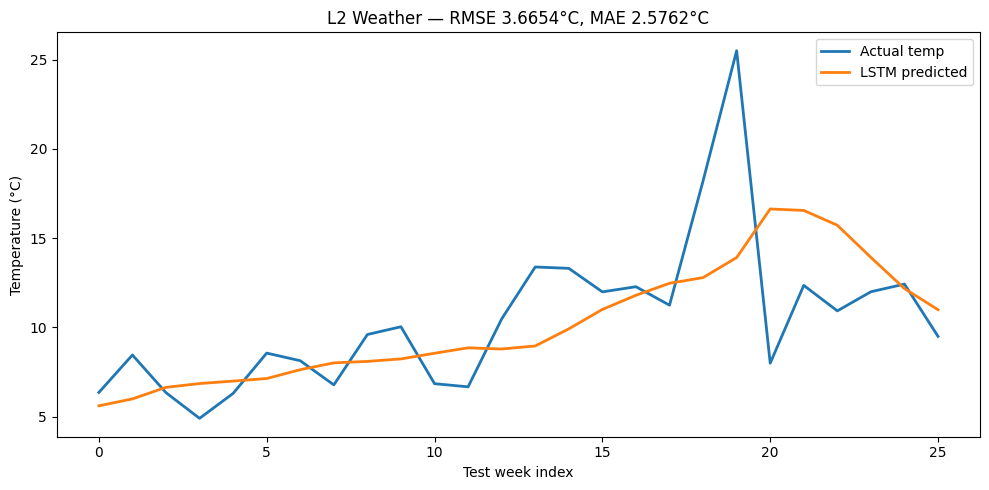

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [5]:
plt.figure(figsize=(10, 5))
plt.plot(y_true, label="Actual temp", linewidth=2)
plt.plot(y_pred, label="LSTM predicted", linewidth=2)
plt.title(f"L2 Weather — RMSE {metrics_c['rmse_celsius']}°C, MAE {metrics_c['mae_celsius']}°C")
plt.xlabel("Test week index")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.tight_layout()
plt.savefig("panel_c_weather_forecast.png", dpi=150)
plt.show()

model.save("lstm_weather.h5")

from google.colab import files
files.download("panel_c_weather_forecast.png")
files.download("metrics_c.json")
files.download("lstm_weather.h5")